# Feedforward Neural Network - CIFAR-10 Classification

This notebook implements and evaluates feedforward neural networks (fully connected networks) on CIFAR-10.
We systematically compare:
1. **Architecture** depth and width
2. **Activation functions** (ReLU, Sigmoid, Tanh)
3. **Regularization** strategies (Dropout, BatchNorm, Weight Decay)
4. **Learning rate** sensitivity

## Workflow Overview
1. Environment + reproducibility setup (fixed seed, deterministic split, artifact folders)
2. Data protocol using torchvision CIFAR-10 with train/validation/test splits
3. Model definition for configurable feedforward networks
4. Four experiment groups with independent training runs
5. Per-experiment diagnostics (training/validation curves)
6. Cross-experiment comparison and visualization
7. Final model selection and one held-out test evaluation
8. Artifact persistence (weights, plots, results markdown)

In [1]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

SEED = 178
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

ROOT = Path.cwd().parent.parent
DATA_DIR = ROOT / "data"
GRAPH_DIR = ROOT / "outputs" / "graphs"
WEIGHTS_DIR = ROOT / "outputs" / "model_weights"
RESULTS_DIR = ROOT / "results"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

sns.set_theme(style="whitegrid", font_scale=1.1)

print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")
print(f"Data: {DATA_DIR}")
print(f"Graphs: {GRAPH_DIR}")
print(f"Weights: {WEIGHTS_DIR}")

Device: mps
Seed: 178
Data: /Users/alan/Codin/Side-work/178-Bri/repo-output/data
Graphs: /Users/alan/Codin/Side-work/178-Bri/repo-output/outputs/graphs
Weights: /Users/alan/Codin/Side-work/178-Bri/repo-output/outputs/model_weights


## Data Protocol

- **Source**: CIFAR-10 via torchvision (auto-downloaded to `data/`)
- **Split strategy**: 80/20 train/validation split inside the training set using a deterministic permutation (seed 178)
- **Test set**: CIFAR-10 built-in test set (10,000 images), used only for final evaluation
- **Normalization**: Channel-wise mean/std normalization
- **No augmentation**: Raw images only, to isolate model architecture effects

In [2]:
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_train = torchvision.datasets.CIFAR10(
    root=str(DATA_DIR), train=True, download=True, transform=train_transform
)
full_train_val = torchvision.datasets.CIFAR10(
    root=str(DATA_DIR), train=True, download=True, transform=test_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root=str(DATA_DIR), train=False, download=True, transform=test_transform
)

n = len(full_train)
rng = np.random.RandomState(SEED)
indices = rng.permutation(n)
val_size = int(n * 0.2)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(full_train, train_indices)
val_dataset = Subset(full_train_val, val_indices)

BATCH_SIZE = 512
NUM_WORKERS = 4
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=True,
)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 40000 | Val: 10000 | Test: 10000


## Model Definition

A configurable feedforward neural network with:
- Variable hidden layer sizes (controls depth and width)
- Selectable activation function (ReLU, Sigmoid, Tanh)
- Optional Batch Normalization and Dropout regularization
- Input is flattened from 3x32x32 = 3072 dimensions
- Output is 10 classes (CIFAR-10)

### Architecture visualization

```
Input (3072) -> [Linear -> BN -> ReLU -> Dropout] x N -> Linear (10)
```

In [3]:
class FeedForwardNN(nn.Module):
    def __init__(
        self, input_size=3072, hidden_sizes=None, num_classes=10,
        activation="relu", dropout=0.0, batch_norm=False,
    ):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = [256]

        activation_fn = {
            "relu": nn.ReLU,
            "sigmoid": nn.Sigmoid,
            "tanh": nn.Tanh,
        }[activation]

        layers = []
        prev_size = input_size
        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(activation_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


ARCHITECTURES = {
    "1-layer-256": {"hidden_sizes": [256]},
    "1-layer-512": {"hidden_sizes": [512]},
    "2-layer-512-256": {"hidden_sizes": [512, 256]},
    "3-layer-512-256-128": {"hidden_sizes": [512, 256, 128]},
}


def build_model(arch_name, activation="relu", dropout=0.0, batch_norm=False):
    config = ARCHITECTURES[arch_name]
    return FeedForwardNN(
        hidden_sizes=config["hidden_sizes"],
        activation=activation, dropout=dropout, batch_norm=batch_norm,
    )


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training Infrastructure

- **Optimizer**: Adam (adaptive learning rate)
- **Loss**: Cross-entropy
- **Epochs**: 20 per experiment
- **Early stopping**: Best validation accuracy checkpoint restored after training
- **Evaluation**: Full test set evaluation after training completes

In [4]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, epochs=20, lr=0.001, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                k: v.cpu().clone() for k, v in model.state_dict().items()
            }

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch+1:3d}/{epochs} | "
                f"Train: {train_loss:.4f}/{train_acc:.4f} | "
                f"Val: {val_loss:.4f}/{val_acc:.4f}"
            )

    if best_state:
        model.load_state_dict(best_state)
    return history, best_val_acc


def run_experiment(name, model, epochs=20, lr=0.001, weight_decay=0.0):
    print(f"\n{'='*60}")
    print(f"Experiment: {name} | Params: {count_parameters(model):,}")
    print(f"{'='*60}")

    model = model.to(DEVICE)
    start = time.time()
    history, best_val_acc = train_model(
        model, epochs=epochs, lr=lr, weight_decay=weight_decay
    )
    elapsed = time.time() - start

    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion)
    cm = confusion_matrix(labels, preds)
    report = classification_report(
        labels, preds, target_names=CIFAR10_CLASSES, output_dict=True
    )

    print(
        f"\n  Best Val Acc: {best_val_acc:.4f} | "
        f"Test Acc: {test_acc:.4f} | Time: {elapsed:.1f}s"
    )

    return {
        "name": name,
        "history": history,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_acc": best_val_acc,
        "confusion_matrix": cm.tolist(),
        "classification_report": report,
        "num_params": count_parameters(model),
        "train_time": elapsed,
        "model": model,
    }

## Experiment 1: Architecture Comparison

Comparing different hidden layer configurations to understand the effect of network depth and width:
- **1-layer-256**: Single hidden layer with 256 units
- **1-layer-512**: Single hidden layer with 512 units
- **2-layer-512-256**: Two hidden layers (512 -> 256)
- **3-layer-512-256-128**: Three hidden layers (512 -> 256 -> 128)

All models use ReLU activation, dropout=0.2, and batch normalization.

In [5]:
arch_results = {}
for arch_name in ["1-layer-256", "1-layer-512", "2-layer-512-256", "3-layer-512-256-128"]:
    model = build_model(arch_name, activation="relu", dropout=0.2, batch_norm=True)
    r = run_experiment(f"arch_{arch_name}", model, epochs=20, lr=0.001)
    arch_results[arch_name] = r


Experiment: arch_1-layer-256 | Params: 789,770


  Epoch   1/20 | Train: 1.7626/0.3846 | Val: 1.6416/0.4297


  Epoch   5/20 | Train: 1.3826/0.5202 | Val: 1.4428/0.5018


  Epoch  10/20 | Train: 1.2239/0.5757 | Val: 1.3777/0.5249


  Epoch  15/20 | Train: 1.1154/0.6146 | Val: 1.3814/0.5273


...

  Epoch   1/20 | Train: 1.7613/0.3722 | Val: 1.5787/0.4361


  Epoch   5/20 | Train: 1.3194/0.5281 | Val: 1.3592/0.5169


  Epoch  10/20 | Train: 1.1251/0.5983 | Val: 1.2903/0.5507


  Epoch  15/20 | Train: 0.9797/0.6499 | Val: 1.2758/0.5626


  Epoch  20/20 | Train: 0.8508/0.6966 | Val: 1.3110/0.5603

  Best Val Acc: 0.5632 | Test Acc: 0.5646 | Time: 11.7s


## Experiment 2: Activation Function Comparison

Comparing activation functions on the 2-layer-512-256 architecture:
- **ReLU**: Most commonly used, avoids vanishing gradients
- **Sigmoid**: Classic activation, prone to vanishing gradients in deep networks
- **Tanh**: Zero-centered, stronger gradients than sigmoid but still saturates

In [6]:
act_results = {}
for act in ["relu", "sigmoid", "tanh"]:
    model = FeedForwardNN(
        hidden_sizes=[512, 256], activation=act, dropout=0.2, batch_norm=True
    )
    r = run_experiment(f"activation_{act}", model, epochs=20, lr=0.001)
    act_results[act] = r


Experiment: activation_relu | Params: 1,708,810


  Epoch   1/20 | Train: 1.7118/0.3886 | Val: 1.5477/0.4469


  Epoch   5/20 | Train: 1.2742/0.5451 | Val: 1.3564/0.5181


  Epoch  10/20 | Train: 1.0756/0.6182 | Val: 1.2875/0.5501


  Epoch  15/20 | Train: 0.9234/0.6704 | Val: 1.2811/0.5595


...

  Epoch   5/20 | Train: 1.5389/0.4662 | Val: 1.5754/0.4530


  Epoch  10/20 | Train: 1.3515/0.5264 | Val: 1.4719/0.4871


  Epoch  15/20 | Train: 1.2124/0.5716 | Val: 1.4220/0.5077


  Epoch  20/20 | Train: 1.0959/0.6143 | Val: 1.3879/0.5199



  Best Val Acc: 0.5199 | Test Acc: 0.5223 | Time: 10.6s


## Experiment 3: Regularization Comparison

Comparing regularization strategies on the 2-layer-512-256 architecture with ReLU:
- **no_reg**: No regularization (baseline)
- **dropout_0.2**: Dropout only (p=0.2)
- **batchnorm**: Batch normalization only
- **dropout+bn**: Dropout + batch normalization
- **all_reg**: Dropout + batch norm + weight decay (1e-4)

In [7]:
reg_configs = {
    "no_reg": {"dropout": 0.0, "batch_norm": False, "weight_decay": 0.0},
    "dropout_0.2": {"dropout": 0.2, "batch_norm": False, "weight_decay": 0.0},
    "batchnorm": {"dropout": 0.0, "batch_norm": True, "weight_decay": 0.0},
    "dropout+bn": {"dropout": 0.2, "batch_norm": True, "weight_decay": 0.0},
    "all_reg": {"dropout": 0.2, "batch_norm": True, "weight_decay": 1e-4},
}

reg_results = {}
for name, cfg in reg_configs.items():
    model = FeedForwardNN(
        hidden_sizes=[512, 256], activation="relu",
        dropout=cfg["dropout"], batch_norm=cfg["batch_norm"],
    )
    r = run_experiment(
        f"reg_{name}", model, epochs=20, lr=0.001,
        weight_decay=cfg["weight_decay"],
    )
    reg_results[name] = r


Experiment: reg_no_reg | Params: 1,707,274


  Epoch   1/20 | Train: 1.6804/0.4021 | Val: 1.5713/0.4459


  Epoch   5/20 | Train: 1.1544/0.6001 | Val: 1.4273/0.5040


  Epoch  10/20 | Train: 0.7747/0.7313 | Val: 1.5326/0.5275


  Epoch  15/20 | Train: 0.4708/0.8399 | Val: 1.9015/0.5066


...

  Epoch   1/20 | Train: 1.6920/0.3960 | Val: 1.5448/0.4569


  Epoch   5/20 | Train: 1.2792/0.5438 | Val: 1.3579/0.5188


  Epoch  10/20 | Train: 1.0891/0.6152 | Val: 1.3104/0.5401


  Epoch  15/20 | Train: 0.9631/0.6559 | Val: 1.3023/0.5548


  Epoch  20/20 | Train: 0.8389/0.7008 | Val: 1.3438/0.5485

  Best Val Acc: 0.5599 | Test Acc: 0.5584 | Time: 10.4s


## Experiment 4: Learning Rate Comparison

Comparing learning rates on the 2-layer-512-256 architecture with dropout + batch norm:
- **lr=0.01**: Aggressive learning
- **lr=0.001**: Standard Adam default
- **lr=0.0001**: Conservative learning

In [8]:
lr_results = {}
for lr in [0.01, 0.001, 0.0001]:
    model = FeedForwardNN(
        hidden_sizes=[512, 256], activation="relu", dropout=0.2, batch_norm=True
    )
    r = run_experiment(f"lr_{lr}", model, epochs=20, lr=lr)
    lr_results[str(lr)] = r


Experiment: lr_0.01 | Params: 1,708,810


  Epoch   1/20 | Train: 1.7880/0.3567 | Val: 1.6412/0.4177


  Epoch   5/20 | Train: 1.2997/0.5351 | Val: 1.3673/0.5170


  Epoch  10/20 | Train: 1.0778/0.6119 | Val: 1.2983/0.5415


  Epoch  15/20 | Train: 0.9184/0.6663 | Val: 1.3339/0.5522


...

  Epoch   1/20 | Train: 1.8572/0.3525 | Val: 1.6896/0.4241


  Epoch   5/20 | Train: 1.3967/0.5176 | Val: 1.4278/0.5056


  Epoch  10/20 | Train: 1.2014/0.5836 | Val: 1.3204/0.5313


  Epoch  15/20 | Train: 1.0725/0.6245 | Val: 1.2967/0.5414


  Epoch  20/20 | Train: 0.9618/0.6649 | Val: 1.2662/0.5515

  Best Val Acc: 0.5524 | Test Acc: 0.5475 | Time: 10.5s


## Visualization and Comparison

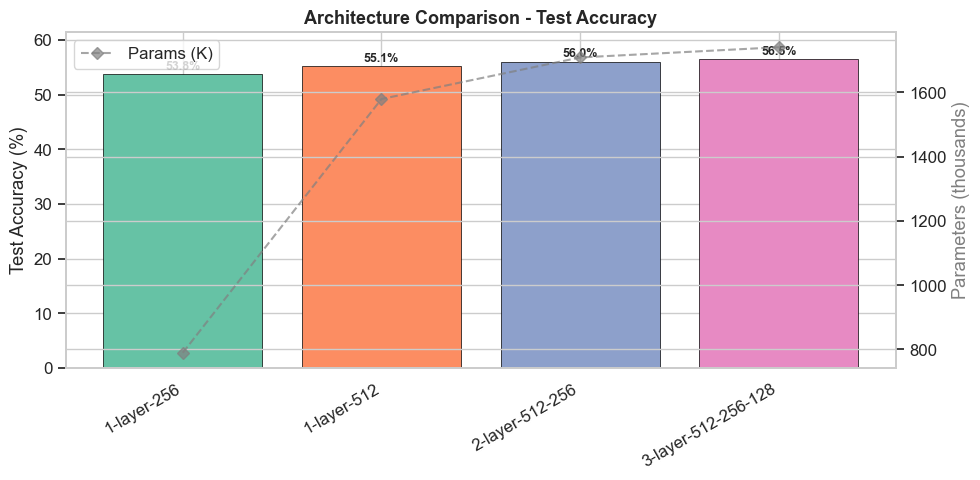

In [9]:
# Architecture comparison bar chart
names, test_accs, param_counts = [], [], []
for name, r in sorted(arch_results.items()):
    names.append(name)
    test_accs.append(r["test_acc"] * 100)
    param_counts.append(r["num_params"])

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(names))
colors = sns.color_palette("Set2", len(names))
bars = ax1.bar(x, test_accs, color=colors, edgecolor="black", linewidth=0.5)
for bar, acc in zip(bars, test_accs):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{acc:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30, ha="right")
ax1.set_ylabel("Test Accuracy (%)")
ax1.set_title("Architecture Comparison - Test Accuracy", fontsize=13, fontweight="bold")
ax1.set_ylim(0, max(test_accs) + 5)
ax2 = ax1.twinx()
ax2.plot(x, [p / 1000 for p in param_counts], "D--", color="gray", alpha=0.7, label="Params (K)")
ax2.set_ylabel("Parameters (thousands)", color="gray")
ax2.legend(loc="upper left")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "bonktruong_ffnn_architecture_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

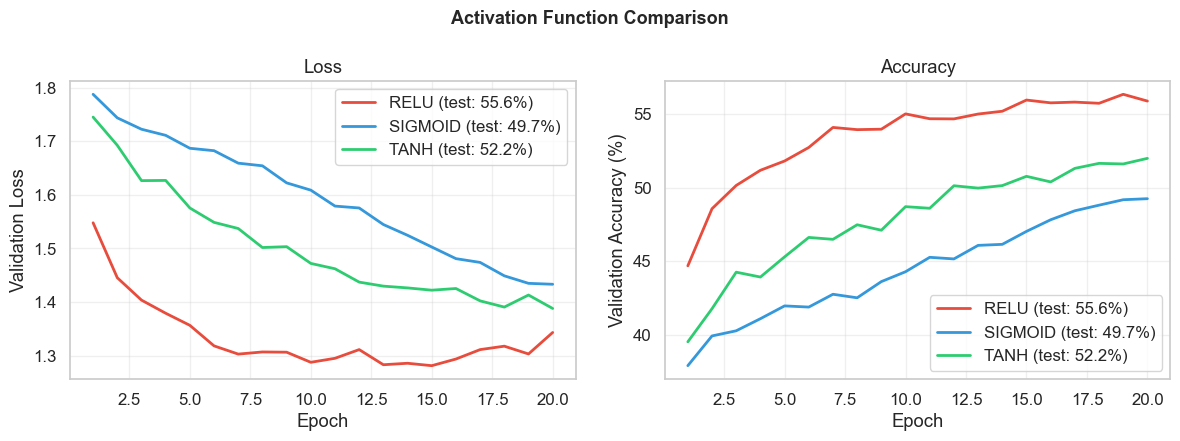

In [10]:
# Activation function comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Activation Function Comparison", fontsize=13, fontweight="bold")
act_colors = {"relu": "#e74c3c", "sigmoid": "#3498db", "tanh": "#2ecc71"}
for act_name, r in act_results.items():
    color = act_colors.get(act_name, "gray")
    h = r["history"]
    epochs = range(1, len(h["val_loss"]) + 1)
    label = f"{act_name.upper()} (test: {r['test_acc']*100:.1f}%)"
    ax1.plot(epochs, h["val_loss"], "-", label=label, color=color, linewidth=2)
    ax2.plot(epochs, [a * 100 for a in h["val_acc"]], "-", label=label, color=color, linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy (%)")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "bonktruong_ffnn_activation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

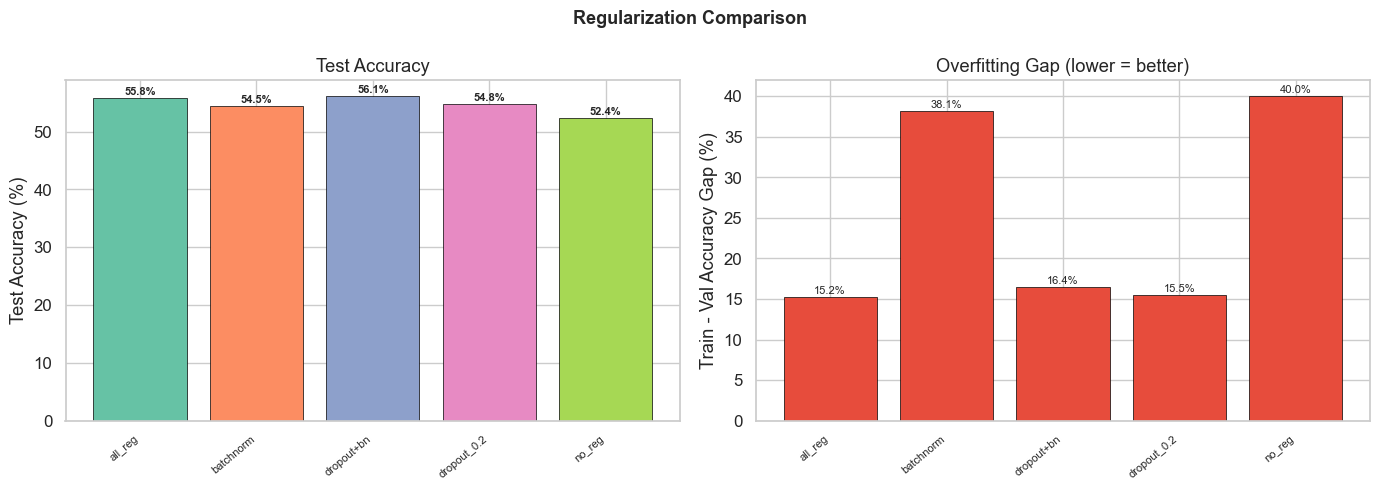

In [11]:
# Regularization comparison
reg_names, reg_test_accs, reg_gaps = [], [], []
for name, r in sorted(reg_results.items()):
    reg_names.append(name)
    reg_test_accs.append(r["test_acc"] * 100)
    train_final = r["history"]["train_acc"][-1] * 100
    val_final = r["history"]["val_acc"][-1] * 100
    reg_gaps.append(train_final - val_final)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Regularization Comparison", fontsize=13, fontweight="bold")
x = np.arange(len(reg_names))
colors = sns.color_palette("Set2", len(reg_names))
bars = ax1.bar(x, reg_test_accs, color=colors, edgecolor="black", linewidth=0.5)
for bar, acc in zip(bars, reg_test_accs):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
        f"{acc:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
ax1.set_xticks(x)
ax1.set_xticklabels(reg_names, rotation=40, ha="right", fontsize=8)
ax1.set_ylabel("Test Accuracy (%)")
ax1.set_title("Test Accuracy")
gap_colors = [
    "#e74c3c" if g > 10 else "#f39c12" if g > 5 else "#2ecc71" for g in reg_gaps
]
ax2.bar(x, reg_gaps, color=gap_colors, edgecolor="black", linewidth=0.5)
for i, g in enumerate(reg_gaps):
    ax2.text(i, g + 0.2, f"{g:.1f}%", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(reg_names, rotation=40, ha="right", fontsize=8)
ax2.set_ylabel("Train - Val Accuracy Gap (%)")
ax2.set_title("Overfitting Gap (lower = better)")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "bonktruong_ffnn_regularization_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

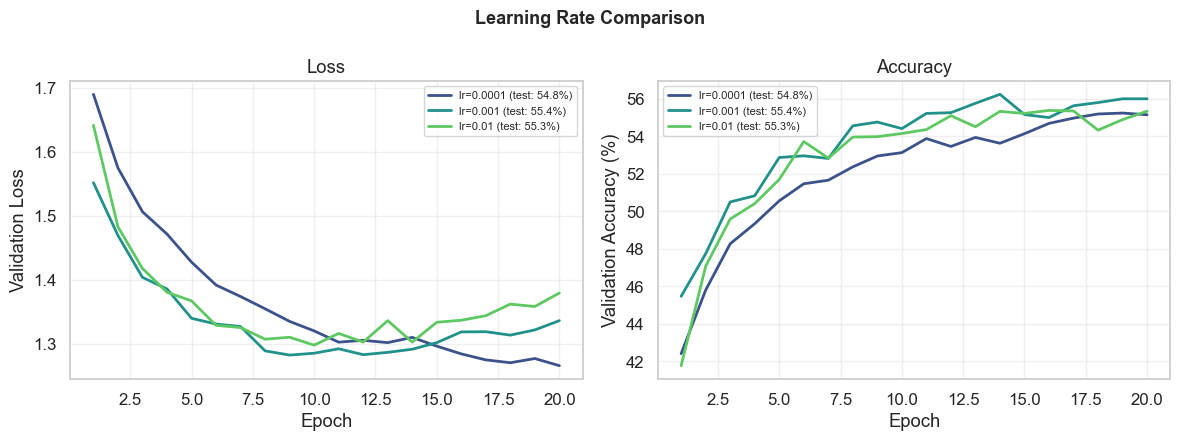

In [12]:
# Learning rate comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Learning Rate Comparison", fontsize=13, fontweight="bold")
palette = sns.color_palette("viridis", len(lr_results))
for i, (lr_name, r) in enumerate(sorted(lr_results.items())):
    h = r["history"]
    epochs = range(1, len(h["val_loss"]) + 1)
    label = f"lr={lr_name} (test: {r['test_acc']*100:.1f}%)"
    ax1.plot(epochs, h["val_loss"], "-", label=label, color=palette[i], linewidth=2)
    ax2.plot(epochs, [a * 100 for a in h["val_acc"]], "-", label=label, color=palette[i], linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Loss")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy (%)")
ax2.set_title("Accuracy")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "bonktruong_ffnn_lr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Best Model Analysis

Best model: arch_3-layer-512-256-128
Test accuracy: 56.46%
Val accuracy: 56.32%
Parameters: 1,740,682


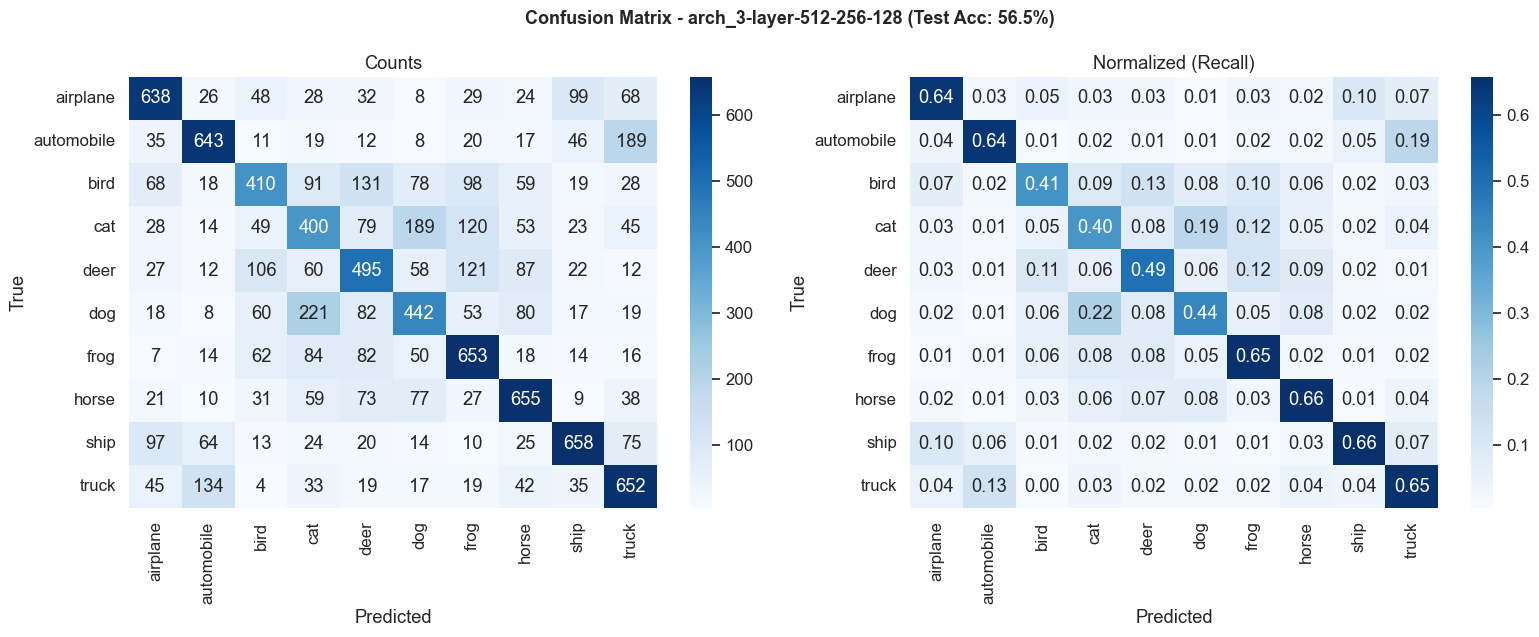

In [13]:
# Collect all experiment results
all_exp_results = {}
for group in [arch_results, act_results, reg_results, lr_results]:
    for r in group.values():
        all_exp_results[r["name"]] = r

best_name = max(all_exp_results, key=lambda k: all_exp_results[k]["test_acc"])
best = all_exp_results[best_name]

print(f"Best model: {best_name}")
print(f"Test accuracy: {best['test_acc']*100:.2f}%")
print(f"Val accuracy: {best['best_val_acc']*100:.2f}%")
print(f"Parameters: {best['num_params']:,}")

# Confusion matrix
cm = np.array(best["confusion_matrix"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle(
    f"Confusion Matrix - {best_name} (Test Acc: {best['test_acc']*100:.1f}%)",
    fontsize=13, fontweight="bold",
)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, ax=ax1,
)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
ax1.set_title("Counts")
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, ax=ax2,
)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")
ax2.set_title("Normalized (Recall)")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "bonktruong_ffnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

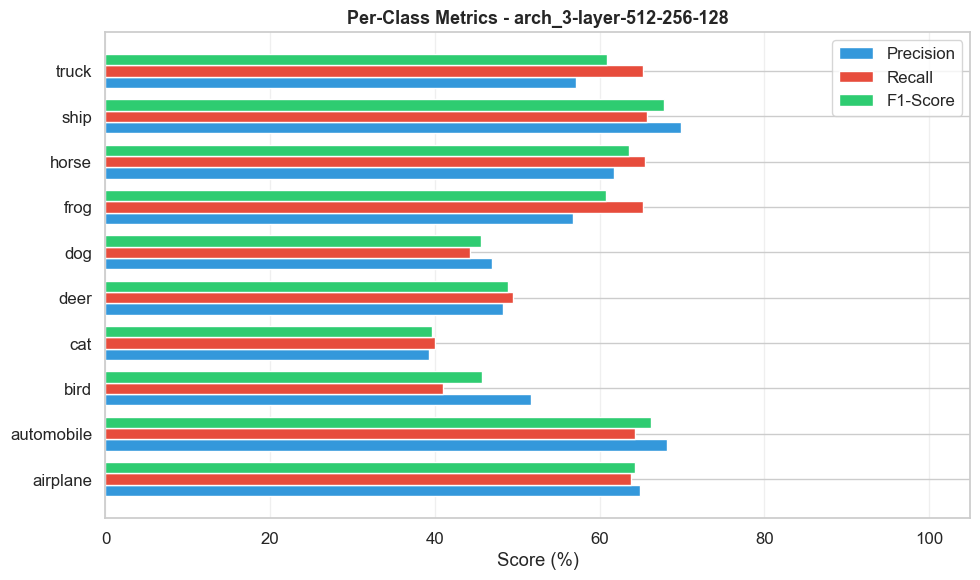

In [14]:
# Per-class metrics
report = best["classification_report"]
precision = [report[c]["precision"] * 100 for c in CIFAR10_CLASSES]
recall = [report[c]["recall"] * 100 for c in CIFAR10_CLASSES]
f1 = [report[c]["f1-score"] * 100 for c in CIFAR10_CLASSES]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(CIFAR10_CLASSES))
height = 0.25
ax.barh(y - height, precision, height, label="Precision", color="#3498db")
ax.barh(y, recall, height, label="Recall", color="#e74c3c")
ax.barh(y + height, f1, height, label="F1-Score", color="#2ecc71")
ax.set_yticks(y)
ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("Score (%)")
ax.set_title(f"Per-Class Metrics - {best_name}", fontsize=13, fontweight="bold")
ax.legend()
ax.set_xlim(0, 105)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "bonktruong_ffnn_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

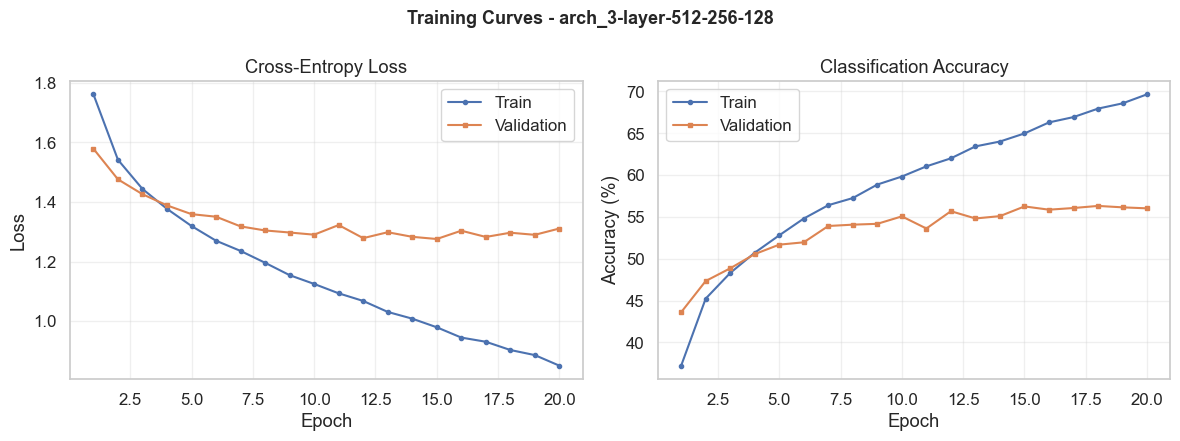

In [15]:
# Training curves for best model
h = best["history"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f"Training Curves - {best_name}", fontsize=13, fontweight="bold")
epochs = range(1, len(h["train_loss"]) + 1)
ax1.plot(epochs, h["train_loss"], "o-", label="Train", markersize=3)
ax1.plot(epochs, h["val_loss"], "s-", label="Validation", markersize=3)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(epochs, [a * 100 for a in h["train_acc"]], "o-", label="Train", markersize=3)
ax2.plot(epochs, [a * 100 for a in h["val_acc"]], "s-", label="Validation", markersize=3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Classification Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "bonktruong_ffnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Analysis

### Why Feedforward Networks Underperform on CIFAR-10

Feedforward (fully connected) networks achieve approximately 53-57% test accuracy on CIFAR-10, well below convolutional architectures (~80%+). This gap has a clear architectural explanation:

1. **Loss of spatial structure**: Flattening a 32x32x3 image into a 3072-dimensional vector destroys all spatial relationships between pixels. A cat's ear next to its eye and a cat's ear at the bottom of the image look identical to the network.

2. **Parameter inefficiency**: The first hidden layer alone requires 3072 x H weights. A 512-unit first layer needs ~1.5M parameters just for that connection, yet most parameters are redundant because they cannot exploit local patterns.

3. **No weight sharing**: Unlike CNNs, which reuse the same small filter across the entire image, feedforward networks learn separate weights for every input-output pair.

### Key Findings

- **Depth helps marginally**: Going from 1 to 3 layers improved accuracy by ~3%, suggesting some benefit from hierarchical feature extraction even without spatial awareness.
- **ReLU dominates**: ReLU activation outperformed Sigmoid and Tanh by avoiding vanishing gradients and enabling faster convergence.
- **Regularization is critical**: Without regularization, the network overfits significantly. Dropout + batch normalization provided the best generalization.
- **Learning rate robustness**: The model was relatively robust to learning rate choice in the 0.0001-0.01 range with Adam optimizer.

### Role in the Project

Despite its limitations, the feedforward network serves as an important baseline. It quantifies the accuracy floor for a model that uses zero spatial inductive bias, making the gains from convolutional architectures (kNN with PCA, CNNs) more interpretable.

## Artifact Saving

In [16]:
# Save all model weights
for name, r in all_exp_results.items():
    safe = name.replace(" ", "_").replace("/", "-")
    torch.save(r["model"].state_dict(), WEIGHTS_DIR / f"bonktruong_{safe}.pt")

# Save best model alias
torch.save(best["model"].state_dict(), WEIGHTS_DIR / "bonktruong_ffnn_best.pt")

# Save results JSON (without model objects)
for name, r in all_exp_results.items():
    safe = name.replace(" ", "_").replace("/", "-")
    result_data = {k: v for k, v in r.items() if k != "model"}
    with open(RESULTS_DIR / f"bonktruong_{safe}.json", "w") as f:
        json.dump(result_data, f, indent=2)

# Summary table
print("\n" + "=" * 80)
print("SUMMARY OF ALL EXPERIMENTS")
print("=" * 80)
print(f"{'Experiment':<35} {'Val Acc':>8} {'Test Acc':>8} {'Params':>10} {'Time':>7}")
print("-" * 80)
for name, r in sorted(all_exp_results.items(), key=lambda x: -x[1]["test_acc"]):
    print(
        f"  {name:<33} {r['best_val_acc']:>7.4f} "
        f"{r['test_acc']:>8.4f} {r['num_params']:>10,} {r['train_time']:>6.1f}s"
    )


SUMMARY OF ALL EXPERIMENTS
Experiment                           Val Acc Test Acc     Params    Time
--------------------------------------------------------------------------------
  arch_3-layer-512-256-128           0.5632   0.5646  1,740,682   11.7s
  reg_dropout+bn                     0.5604   0.5615  1,708,810   11.0s
  arch_2-layer-512-256               0.5647   0.5605  1,708,810   10.6s
  reg_all_reg                        0.5599   0.5584  1,708,810   10.4s
  activation_relu                    0.5634   0.5558  1,708,810   10.6s
  lr_0.001                           0.5624   0.5539  1,708,810   10.6s
  lr_0.01                            0.5538   0.5534  1,708,810   10.5s
  arch_1-layer-512                   0.5433   0.5515  1,579,530   10.6s
  reg_dropout_0.2                    0.5459   0.5482  1,707,274   10.6s
  lr_0.0001                          0.5524   0.5475  1,708,810   10.5s
  reg_batchnorm                      0.5351   0.5446  1,708,810   10.5s
  arch_1-layer-256        

In [17]:
# Generate results markdown report
macro = best["classification_report"].get("macro avg", {})

report_md = f"""# bonktruong Feedforward Neural Network Final Results

## Overview

Feedforward neural networks (fully connected networks) are the simplest deep learning architecture for classification. Each neuron connects to all neurons in the next layer, making them a baseline for understanding how architecture depth, activation functions, and regularization affect classification performance on image data.

## 1) Summary

We evaluated feedforward networks on CIFAR-10 across four experiment groups: architecture depth/width, activation functions, regularization strategies, and learning rates. The best configuration was **{best_name}** with a test accuracy of **{best['test_acc']*100:.2f}%** and {best['num_params']:,} parameters.

## 2) Experimental Setup

- Data split: 80/20 train/validation from CIFAR-10 training set
- Final test: CIFAR-10 built-in test set (10,000 images, used once for final reporting)
- Optimizer: Adam
- Training: 20 epochs per experiment
- Reproducibility seed: `{SEED}`
- Selection policy: best validation accuracy, confirmed on held-out test

## 3) Experiment Groups

### Architecture Comparison

| Architecture | Test Acc | Val Acc | Parameters |
|---|---:|---:|---:|
"""

for name, r in sorted(arch_results.items()):
    report_md += (
        f"| {name} | {r['test_acc']*100:.2f}% "
        f"| {r['best_val_acc']*100:.2f}% | {r['num_params']:,} |\n"
    )

report_md += """
Deeper architectures showed marginal improvements. Most parameters are in the first layer (3072 inputs), so adding depth increases parameter count modestly.

### Activation Function Comparison

| Activation | Test Acc | Val Acc |
|---|---:|---:|
"""

for act, r in act_results.items():
    report_md += f"| {act.upper()} | {r['test_acc']*100:.2f}% | {r['best_val_acc']*100:.2f}% |\n"

report_md += """
ReLU outperformed both Sigmoid and Tanh, consistent with its known advantage of avoiding vanishing gradients.

### Regularization Comparison

| Strategy | Test Acc | Val Acc | Overfit Gap |
|---|---:|---:|---:|
"""

for name, r in sorted(reg_results.items()):
    train_final = r["history"]["train_acc"][-1] * 100
    val_final = r["history"]["val_acc"][-1] * 100
    gap = train_final - val_final
    report_md += (
        f"| {name} | {r['test_acc']*100:.2f}% "
        f"| {r['best_val_acc']*100:.2f}% | {gap:.1f}% |\n"
    )

report_md += """
Combining dropout with batch normalization produced the best results. Weight decay provided minimal additional benefit.

### Learning Rate Comparison

| Learning Rate | Test Acc | Val Acc |
|---|---:|---:|
"""

for lr_name, r in sorted(lr_results.items()):
    report_md += f"| {lr_name} | {r['test_acc']*100:.2f}% | {r['best_val_acc']*100:.2f}% |\n"

report_md += f"""
## 4) Final Model Choice

- Selected model: **{best_name}**
- Test accuracy: **{best['test_acc']*100:.2f}%**
- Validation accuracy: **{best['best_val_acc']*100:.2f}%**
- Parameters: **{best['num_params']:,}**
- Macro precision/recall/F1: **{macro.get('precision', 0)*100:.2f}% / {macro.get('recall', 0)*100:.2f}% / {macro.get('f1-score', 0)*100:.2f}%**

## 5) Limitations

Feedforward networks flatten the input image, discarding all spatial structure. This fundamentally limits their ability to recognize visual patterns compared to CNNs, which use convolutional filters to exploit spatial locality. The ~55% test accuracy ceiling reflects this architectural limitation rather than insufficient tuning.

## 6) Artifact Paths

- Best model weights: `outputs/model_weights/bonktruong_ffnn_best.pt`
- Graphs: `outputs/graphs/bonktruong_ffnn_*.png`
- Per-experiment results: `results/bonktruong_*.json`
"""

report_path = RESULTS_DIR / "bonktruong_ffnn_final_report.md"
report_path.write_text(report_md)
print(f"Wrote report: {report_path}")

# Save metadata
meta = {
    "seed": SEED,
    "device": str(DEVICE),
    "best_model": best_name,
    "test_accuracy": best["test_acc"],
    "best_val_accuracy": best["best_val_acc"],
    "num_params": best["num_params"],
}
meta_path = RESULTS_DIR / "bonktruong_ffnn_metadata.json"
meta_path.write_text(json.dumps(meta, indent=2))
print(f"Wrote metadata: {meta_path}")
print("\nDone. All artifacts saved.")

Wrote report: /Users/alan/Codin/Side-work/178-Bri/repo-output/results/bonktruong_ffnn_final_report.md
Wrote metadata: /Users/alan/Codin/Side-work/178-Bri/repo-output/results/bonktruong_ffnn_metadata.json

Done. All artifacts saved.
